In [80]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [81]:
df = pd.read_csv('placement (2).csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package (in lpa)')

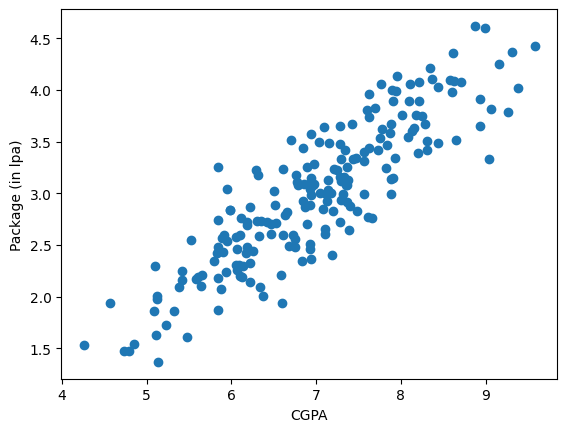

In [82]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package (in lpa)')

In [83]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [84]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [85]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Text(0, 0.5, 'Package (in lpa)')

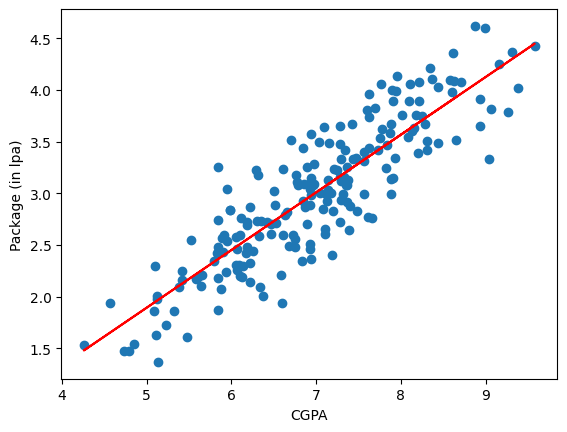

In [86]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package (in lpa)')

In [87]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [88]:
y_pred = lr.predict(X_test)

In [89]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [90]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.2884710931878175


In [91]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.12129235313495527


In [92]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.34827051717731616


In [93]:
print("R2 Score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 Score 0.780730147510384


In [94]:
# Adjusted R2 score
X_test.shape

(40, 1)

In [95]:
1-((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

In [96]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)
new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.660828,3.26
1,5.12,0.331437,1.98
2,7.82,0.286054,3.25
3,7.42,0.825038,3.67
4,6.94,0.001840,3.57


Text(0, 0.5, 'Package(in lpa)')

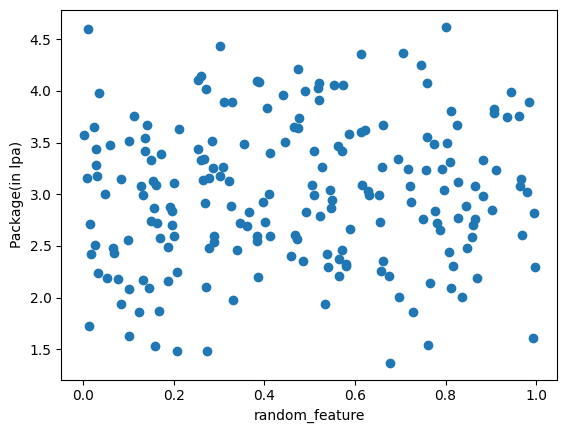

In [97]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [98]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [99]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [100]:
y_pred = lr.predict(X_test)

In [101]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7784940519914015


In [102]:
1-((1-r2)*(40-1)/(40-1-1))

0.7726649480964385

In [103]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]
new_df2.sample(5)


,cgpa,iq,package
154,7.08,3.45,2.85
146,6.07,3.46,2.46
85,4.79,0.98,1.48
90,7.11,3.36,2.66
151,6.12,2.46,2.76


Text(0, 0.5, 'Package(in lpa)')

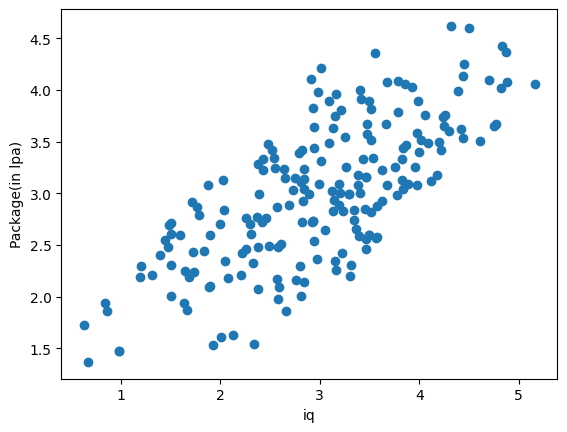

In [104]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [105]:
np.random.randint(-100,100)

-33

In [106]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [107]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [108]:
y_pred = lr.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))

R2 score 0.8034903884882266


In [109]:
r2 = r2_score(y_test,y_pred)

In [110]:
1-((1-r2)*(40-1)/(40-1-1))

0.7983190829221274